In [1]:
# CÉLULA 1: INSTALAÇÃO, IMPORTAÇÃO E CONFIGURAÇÃO

# Ação: Instalação e atualização centralizada de todas as bibliotecas.
print("Instalando e atualizando bibliotecas essenciais...")
!pip install pandas pyarrow lightgbm xgboost catboost scikit-learn optuna matplotlib seaborn psutil -q
!pip install --upgrade xgboost -q

# Importação de todos os módulos
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import gc
import os
import psutil
import matplotlib.pyplot as plt
import seaborn as sns

# Verificação de versão
print(f"Versão do XGBoost carregada: {xgb.__version__}")
print("\n✅ Instalações e importações concluídas!")


# Funções de utilidade e métricas customizadas
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return f"{process.memory_info().rss / (1024 ** 3):.2f} GB"

def wmate(y_true, y_pred):
    y_true_np, y_pred_np = np.array(y_true), np.array(y_pred)
    y_true_tanh, y_pred_tanh = np.tanh(y_true_np), np.tanh(y_pred_np)
    weights = np.tanh(y_true_np)
    absolute_error = np.abs(y_true_tanh - y_pred_tanh)
    weighted_absolute_error = weights * absolute_error
    sum_weights = np.sum(weights)
    return np.sum(weighted_absolute_error) / sum_weights if sum_weights != 0 else 0.0

# Wrappers da métrica para as APIs dos modelos
def lgbm_wmate(y_true, y_pred):
    return 'wmate', wmate(y_true, y_pred), False

def xgb_wmate(y_pred, y_true):
    y_true = y_true.get_label()
    score = wmate(y_true, y_pred)
    return [('wmate', score)]

class CatBoostWmate:
    def is_max_optimal(self): return False
    def evaluate(self, approxes, target, weight): return wmate(target, approxes[0]), 0
    def get_final_error(self, error, weight): return error

print(f"Uso de RAM inicial: {get_memory_usage()}")

# Montar o Google Drive (se estiver no Colab)
# from google.colab import drive
# drive.mount('/content/drive')

Instalando e atualizando bibliotecas essenciais...

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


/home/gilliard/PycharmProjects/desafio_forecast/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Versão do XGBoost carregada: 3.0.5

✅ Instalações e importações concluídas!
Uso de RAM inicial: 0.29 GB


In [2]:
# CÉLULA 2: CARREGAMENTO, JUNÇÃO E TRATAMENTO INICIAL

print("Iniciando carregamento dos dados brutos...")
# AJUSTE O CAMINHO PARA SEU AMBIENTE LOCAL OU DO DRIVE
base_path = './' # Exemplo para local
# base_path = '/content/drive/MyDrive/hackathon_2025_templates/' # Exemplo para Drive
path_pdv = f'{base_path}data_parquet/part-00000-tid-2779033056155408584-f6316110-4c9a-4061-ae48-69b77c7c8c36-4-1-c000.snappy.parquet'
path_sales = f'{base_path}data_parquet/part-00000-tid-5196563791502273604-c90d3a24-52f2-4955-b4ec-fb143aae74d8-4-1-c000.snappy.parquet'
path_products = f'{base_path}data_parquet/part-00000-tid-7173294866425216458-eae53fbf-d19e-4130-ba74-78f96b9675f1-4-1-c000.snappy.parquet'

df_pdv = pd.read_parquet(path_pdv)
df_sales = pd.read_parquet(path_sales)
df_products = pd.read_parquet(path_products)
print("Dados carregados.")

# Junção e Limpeza
df_pdv.rename(columns={'pdv': 'internal_store_id'}, inplace=True)
df_products.rename(columns={'produto': 'internal_product_id'}, inplace=True)
df_master = pd.merge(df_sales, df_products, on='internal_product_id', how='left')
df_master = pd.merge(df_master, df_pdv, on='internal_store_id', how='left')
del df_pdv, df_sales, df_products; gc.collect()

print(f"DataFrame Mestre criado com {df_master.shape[0]:,} linhas.")
print("Iniciando tratamento de tipos e valores nulos...")
df_master['transaction_date'] = pd.to_datetime(df_master['transaction_date'])
cols_to_fill = ['subcategoria', 'premise', 'categoria_pdv']
for col in cols_to_fill:
    df_master[col].fillna('Desconhecido', inplace=True)
df_master['zipcode'].fillna('00000', inplace=True)
df_master['zipcode'] = df_master['zipcode'].astype(str)

print("Agregando dados para o nível diário (produto-loja-dia)...")
static_cols = ['categoria', 'subcategoria', 'marca', 'fabricante', 'premise', 'categoria_pdv', 'zipcode']
agg_dict = {'quantity': 'sum'}
for col in static_cols:
    agg_dict[col] = 'first'
df_daily = df_master.groupby(
    ['internal_product_id', 'internal_store_id', 'transaction_date']
).agg(agg_dict).reset_index()

del df_master; gc.collect()

print(f"Agregação concluída. Shape: {df_daily.shape}. Uso de RAM: {get_memory_usage()}")

Iniciando carregamento dos dados brutos...
Dados carregados.
DataFrame Mestre criado com 6,560,698 linhas.
Iniciando tratamento de tipos e valores nulos...


/tmp/ipykernel_149991/4082374261.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_master[col].fillna('Desconhecido', inplace=True)
/tmp/ipykernel_149991/4082374261.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

Agregando dados para o nível diário (produto-loja-dia)...
Agregação concluída. Shape: (6560276, 11). Uso de RAM: 2.37 GB
Agregação concluída. Shape: (6560276, 11). Uso de RAM: 2.38 GB


In [3]:
# CÉLULA 3: ENGENHARIA DE FEATURES AVANÇADA

print("Criando features de calendário e preço...")
df_daily['day_of_week_sin'] = np.sin(2 * np.pi * df_daily['transaction_date'].dt.weekday / 7)
df_daily['day_of_week_cos'] = np.cos(2 * np.pi * df_daily['transaction_date'].dt.weekday / 7)
df_daily['month_sin'] = np.sin(2 * np.pi * df_daily['transaction_date'].dt.month / 12)
df_daily['month_cos'] = np.cos(2 * np.pi * df_daily['transaction_date'].dt.month / 12)

# Simulação de preço
df_daily['categoria_code'] = df_daily['categoria'].astype('category').cat.codes
df_daily['date_ordinal'] = df_daily['transaction_date'].apply(lambda x: x.toordinal())
price_trend = (df_daily['date_ordinal'] - df_daily['date_ordinal'].min()) * 0.01
random_noise = np.random.rand(len(df_daily)) * 2
df_daily['preco'] = df_daily['categoria_code'] % 5 + 10 + price_trend + random_noise
df_daily.drop(columns=['categoria_code', 'date_ordinal'], inplace=True)

print("Calculando features de janela móvel e volatilidade...")
df_daily.sort_values(by=['internal_product_id', 'internal_store_id', 'transaction_date'], inplace=True)
grouped_ts = df_daily.groupby(['internal_product_id', 'internal_store_id'])

# Features de Lag e Rolling para Vendas
lags = [7, 14, 28]
for lag in lags:
    df_daily[f'sales_lag_{lag}'] = grouped_ts['quantity'].transform(lambda x: x.shift(lag))
windows = [7, 14, 28]
for window in windows:
    df_daily[f'sales_rolling_mean_{window}'] = grouped_ts['quantity'].transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
    # [MELHORIA] Adiciona a volatilidade (desvio padrão) das vendas
    df_daily[f'sales_rolling_std_{window}'] = grouped_ts['quantity'].transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).std())

df_daily['sales_trend_7_vs_28'] = df_daily['sales_rolling_mean_7'] - df_daily['sales_rolling_mean_28']

# Features de Rolling para Preço
df_daily['preco_medio_7d'] = grouped_ts['preco'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df_daily['variacao_preco_vs_28d'] = df_daily['preco'] / grouped_ts['preco'].transform(lambda x: x.shift(1).rolling(window=28, min_periods=1).mean())
# [MELHORIA] Adiciona a volatilidade (desvio padrão) do preço
df_daily['preco_rolling_std_7d'] = grouped_ts['preco'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).std())


df_daily.fillna(0, inplace=True)

print("Criando a variável alvo 'sales_next_7_days'...")
df_daily['sales_next_7_days'] = grouped_ts['quantity'].transform(lambda x: x.shift(-7).rolling(window=7, min_periods=1).sum())
df_daily.dropna(subset=['sales_next_7_days'], inplace=True)

del grouped_ts; gc.collect()

print(f"DataFrame final pronto com {df_daily.shape[0]:,} linhas.")
print(f"Uso de RAM: {get_memory_usage()}")

# Salvar o novo checkpoint com features melhoradas
output_path = f'{base_path}df_model_ready_final_v2.parquet'
df_daily.to_parquet(output_path, index=False)
print(f"Checkpoint com features avançadas salvo em: {output_path}")

Criando features de calendário e preço...
Calculando features de janela móvel e volatilidade...
Criando a variável alvo 'sales_next_7_days'...
DataFrame final pronto com 4,540,426 linhas.
Uso de RAM: 3.17 GB
Checkpoint com features avançadas salvo em: ./df_model_ready_final_v2.parquet


In [4]:
# CÉLULA 4: PREPARAÇÃO PARA MODELAGEM

# Se você já executou até a Célula 3, pode carregar o checkpoint diretamente
# df_daily = pd.read_parquet('/home/gilliard/PycharmProjects/desafio_forecast/df_model_ready_final_v2.parquet')

print("Preparando X e y...")
features = [col for col in df_daily.columns if col not in [
    'internal_product_id', 'internal_store_id', 'transaction_date',
    'quantity', 'sales_next_7_days'
]]
target = 'sales_next_7_days'
categorical_features = df_daily.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_features:
    df_daily[col] = df_daily[col].astype('category').cat.codes

X = df_daily[features]
y = df_daily[target]

del df_daily; gc.collect()

print("Definindo a estratégia de TimeSeries Cross-Validation...")
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f"Pronto para treinar com {N_SPLITS} folds. Shape de X: {X.shape}")

Preparando X e y...
Definindo a estratégia de TimeSeries Cross-Validation...
Pronto para treinar com 3 folds. Shape de X: (4540426, 25)


In [5]:
# CÉLULA 5: OTIMIZAÇÃO DE HIPERPARÂMETROS (HPO) PARA TODOS OS MODELOS

# Usamos o penúltimo split para o estudo (um conjunto de treino/val menor para agilidade)
train_idx, val_idx = list(tscv.split(X))[-2]
X_train_hpo, X_val_hpo = X.iloc[train_idx], X.iloc[val_idx]
y_train_hpo, y_val_hpo = y.iloc[train_idx], y.iloc[val_idx]

# --- HPO para LightGBM ---
def objective_lgbm(trial):
    params = {
        'objective': 'regression_l1', 'metric': 'mae', 'random_state': 42, 'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train_hpo, y_train_hpo, eval_set=[(X_val_hpo, y_val_hpo)],
              eval_metric=lgbm_wmate, callbacks=[lgb.early_stopping(30, verbose=False)])
    return model.best_score_['valid_0']['wmate']

print("Iniciando estudo de HPO para LightGBM...")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgbm, n_trials=15) # Ajustado para 15 trials para um bom equilíbrio
best_lgb_params = {**study_lgb.best_params, 'objective': 'regression_l1', 'metric': 'mae', 'n_estimators': 2000, 'random_state': 42}
print(f"\nMelhores parâmetros para LightGBM encontrados: {best_lgb_params}")

# --- HPO para XGBoost (com API Nativa - CORRIGIDO) ---
dtrain_hpo = xgb.DMatrix(X_train_hpo, label=y_train_hpo)
dval_hpo = xgb.DMatrix(X_val_hpo, label=y_val_hpo)

def objective_xgb(trial):
    params = {
        'objective': 'reg:squarederror', 'eval_metric': 'mae', 'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = xgb.train(params, dtrain_hpo, num_boost_round=1000,
                      evals=[(dval_hpo, 'eval')], custom_metric=xgb_wmate,
                      early_stopping_rounds=30, verbose_eval=False)
    preds = model.predict(dval_hpo, iteration_range=(0, model.best_iteration + 1))
    return wmate(y_val_hpo, preds)

print("\nIniciando estudo de HPO para XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=15)
best_xgb_params = {**study_xgb.best_params, 'objective': 'reg:squarederror', 'eval_metric': 'mae', 'random_state': 42}
print(f"Melhores parâmetros para XGBoost encontrados: {best_xgb_params}")

# --- HPO para CatBoost ---
def objective_cat(trial):
    params = {
        'loss_function': 'MAE', 'random_seed': 42, 'verbose': 0, 'iterations': 1000,
        'eval_metric': CatBoostWmate(),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
    }
    model = cb.CatBoostRegressor(**params)
    model.fit(X_train_hpo, y_train_hpo, eval_set=[(X_val_hpo, y_val_hpo)],
              early_stopping_rounds=30, use_best_model=True)
    return model.get_best_score()['validation']['CatBoostWmate']

print("\nIniciando estudo de HPO para CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=15)
best_cat_params = {**study_cat.best_params, 'loss_function': 'MAE', 'random_seed': 42, 'verbose': 0, 'iterations': 2000, 'eval_metric': CatBoostWmate()}
print(f"Melhores parâmetros para CatBoost encontrados: {best_cat_params}")

del X_train_hpo, X_val_hpo, y_train_hpo, y_val_hpo, dtrain_hpo, dval_hpo; gc.collect()

[I 2025-09-20 21:38:05,878] A new study created in memory with name: no-name-f9349063-5574-492d-a2e7-4b12686c2aaf


Iniciando estudo de HPO para LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3815
[LightGBM] [Info] Number of data points in the train set: 2270214, number of used features: 25
[LightGBM] [Info] Start training from score 9.000000


[I 2025-09-20 21:39:15,456] Trial 0 finished with value: 0.012272174054706283 and parameters: {'learning_rate': 0.026781245084881226, 'num_leaves': 119, 'subsample': 0.6872396668030448, 'colsample_bytree': 0.741007085393748, 'reg_alpha': 0.025314486244633977, 'reg_lambda': 0.07328711520166395}. Best is trial 0 with value: 0.012272174054706283.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3815
[LightGBM] [Info] Number of data points in the train set: 2270214, number of used features: 25
[LightGBM] [Info] Start training from score 9.000000


[I 2025-09-20 21:39:39,982] Trial 1 finished with value: 0.012463330963911348 and parameters: {'learning_rate': 0.03363359075274964, 'num_leaves': 43, 'subsample': 0.9632896130533067, 'colsample_bytree': 0.9585003682235518, 'reg_alpha': 0.017274418415503586, 'reg_lambda': 0.005147894442911151}. Best is trial 0 with value: 0.012272174054706283.


...

[I 2025-09-20 21:52:41,055] Trial 0 finished with value: 0.014708567567586827 and parameters: {'learning_rate': 0.028674398143256515, 'max_depth': 10, 'subsample': 0.94843528323532, 'colsample_bytree': 0.911747952110251}. Best is trial 0 with value: 0.014708567567586827.
[I 2025-09-20 21:52:48,503] Trial 1 finished with value: 0.014708567567586827 and parameters: {'learning_rate': 0.019311559072572437, 'max_depth': 8, 'subsample': 0.6329130883539674, 'colsample_bytree': 0.7983336659685792}. Best is trial 0 with value: 0.014708567567586827.
[I 2025-09-20 21:52:53,754] Trial 2 finished with value: 0.014708567567586827 and parameters: {'learning_rate': 0.028442037984633538, 'max_depth': 4, 'subsample': 0.717447034001689, 'colsample_bytree': 0.7380323740423486}. Best is trial 0 with value: 0.014708567567586827.
[I 2025-09-20 21:52:56,699] Trial 3 finished with value: 0.014708567567586827 and parameters: {'learning_rate': 0.01742049782468086, 'max_depth': 4, 'subsample': 0.8977625331763415,

Melhores parâmetros para XGBoost encontrados: {'learning_rate': 0.037745551219110406, 'max_depth': 10, 'subsample': 0.9901616756335392, 'colsample_bytree': 0.6822803952975035, 'objective': 'reg:squarederror', 'eval_metric': 'mae', 'random_state': 42}

Iniciando estudo de HPO para CatBoost...


[I 2025-09-20 21:59:19,757] Trial 0 finished with value: 0.01308038582694592 and parameters: {'learning_rate': 0.01047271357612637, 'depth': 6, 'l2_leaf_reg': 0.019493120728339326}. Best is trial 0 with value: 0.01308038582694592.
[I 2025-09-20 22:00:26,037] Trial 1 finished with value: 0.012534425926464601 and parameters: {'learning_rate': 0.03486586295823692, 'depth': 9, 'l2_leaf_reg': 0.20817712337330466}. Best is trial 1 with value: 0.012534425926464601.
[I 2025-09-20 22:01:26,164] Trial 2 finished with value: 0.013479285793614433 and parameters: {'learning_rate': 0.01238920413671507, 'depth': 4, 'l2_leaf_reg': 3.2898765632252767}. Best is trial 1 with value: 0.012534425926464601.
[I 2025-09-20 22:03:02,182] Trial 3 finished with value: 0.01278587665564067 and parameters: {'learning_rate': 0.01822921439077545, 'depth': 7, 'l2_leaf_reg': 0.20380878855101317}. Best is trial 1 with value: 0.012534425926464601.
[I 2025-09-20 22:03:51,315] Trial 4 finished with value: 0.0125180137875442

Melhores parâmetros para CatBoost encontrados: {'learning_rate': 0.0484138255088522, 'depth': 10, 'l2_leaf_reg': 0.06399428618778022, 'loss_function': 'MAE', 'random_seed': 42, 'verbose': 0, 'iterations': 2000, 'eval_metric': <__main__.CatBoostWmate object at 0x7f3f45dbd590>}


45

In [6]:
# CÉLULA 6: TREINAMENTO DE MÚLTIPLOS MODELOS (COM PARÂMETROS OTIMIZADOS)

oof_preds = { 'lgbm': np.zeros(len(X)), 'xgb': np.zeros(len(X)), 'cat': np.zeros(len(X)) }
test_preds = { 'lgbm': [], 'xgb': [], 'cat': [] }
feature_importances = pd.DataFrame(index=X.columns)

splits = list(tscv.split(X))
train_full_indices, test_indices = splits[-1]
X_train_full, X_test = X.iloc[train_full_indices], X.iloc[test_indices]
y_train_full, y_test = y.iloc[train_full_indices], y.iloc[test_indices]

print(f"\nIniciando o treinamento com {len(splits)}-Fold CV...")
for fold, (train_idx, val_idx) in enumerate(splits):
    print(f"\n===== FOLD {fold+1}/{len(splits)} ======")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- LightGBM ---
    print("Treinando LightGBM...")
    model_lgb = lgb.LGBMRegressor(**best_lgb_params)
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  eval_metric=lgbm_wmate, callbacks=[lgb.early_stopping(30, verbose=False)])
    oof_preds['lgbm'][val_idx] = model_lgb.predict(X_val)
    test_preds['lgbm'].append(model_lgb.predict(X_test))
    print(f"  LGBM WMATE Fold {fold+1}: {model_lgb.best_score_['valid_0']['wmate']:.5f}")

    # --- XGBoost (API Nativa) ---
    print("Treinando XGBoost...")
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    dtest = xgb.DMatrix(X_test)
    model_xgb = xgb.train(best_xgb_params, dtrain, num_boost_round=2000,
                          evals=[(dval, 'eval')], custom_metric=xgb_wmate,
                          early_stopping_rounds=30, verbose_eval=False)
    oof_preds['xgb'][val_idx] = model_xgb.predict(dval, iteration_range=(0, model_xgb.best_iteration + 1))
    test_preds['xgb'].append(model_xgb.predict(dtest, iteration_range=(0, model_xgb.best_iteration + 1)))
    xgb_wmate_score = wmate(y_val, oof_preds['xgb'][val_idx])
    print(f"  XGB WMATE Fold {fold+1}: {xgb_wmate_score:.5f}")

    # --- CatBoost ---
    print("Treinando CatBoost...")
    model_cat = cb.CatBoostRegressor(**best_cat_params)
    model_cat.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  early_stopping_rounds=30, use_best_model=True)
    oof_preds['cat'][val_idx] = model_cat.predict(X_val)
    test_preds['cat'].append(model_cat.predict(X_test))
    cat_wmate_score = model_cat.get_best_score()['validation']['CatBoostWmate']
    print(f"  CatBoost WMATE Fold {fold+1}: {cat_wmate_score:.5f}")

    gc.collect()

print("\n✅ Treinamento de todos os modelos concluído.")


Iniciando o treinamento com 3-Fold CV...

===== FOLD 1/3 ======
Treinando LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3711
[LightGBM] [Info] Number of data points in the train set: 1135108, number of used features: 25
[LightGBM] [Info] Start training from score 9.000000
  LGBM WMATE Fold 1: 0.01132
Treinando XGBoost...
  XGB WMATE Fold 1: 0.01365
Treinando CatBoost...


/home/gilliard/PycharmProjects/desafio_forecast/.venv/lib/python3.13/site-packages/catboost/core.py:2321: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


  CatBoost WMATE Fold 1: 0.01156

===== FOLD 2/3 ======
Treinando LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3815
[LightGBM] [Info] Number of data points in the train set: 2270214, number of used features: 25
[LightGBM] [Info] Start training from score 9.000000
  LGBM WMATE Fold 2: 0.01227
Treinando XGBoost...
  XGB WMATE Fold 2: 0.01328
Treinando CatBoost...


/home/gilliard/PycharmProjects/desafio_forecast/.venv/lib/python3.13/site-packages/catboost/core.py:2321: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


  CatBoost WMATE Fold 2: 0.01244

===== FOLD 3/3 ======
Treinando LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3844
[LightGBM] [Info] Number of data points in the train set: 3405320, number of used features: 25
[LightGBM] [Info] Start training from score 8.000000
  LGBM WMATE Fold 3: 0.01163
Treinando XGBoost...
  XGB WMATE Fold 3: 0.01293
Treinando CatBoost...


/home/gilliard/PycharmProjects/desafio_forecast/.venv/lib/python3.13/site-packages/catboost/core.py:2321: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


  CatBoost WMATE Fold 3: 0.01181

✅ Treinamento de todos os modelos concluído.



_Avaliando o desempenho dos modelos individuais (Out-of-Fold)..._
  LGBM OOF WMATE: 0.33725
  XGB OOF WMATE:  0.33837
  CAT OOF WMATE:  0.33739

_Criando meta-features para o Stacking Ensemble..._
Treinando o Meta-Modelo (LightGBM)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 3405320, number of used features: 3
[LightGBM] [Info] Start training from score 8.000000

--- RESULTADOS FINAIS DO STACKING ENSEMBLE ---
  WMATE (Métrica Principal): 0.01169
  MAE (Erro Absoluto Médio): 5.2209
  R² (Coeficiente de Determinação): 0.7151

Importância das features do Meta-Modelo (pesos do ensemble):
  Modelo Base  Importância
0   lgbm_pred         7321
2    cat_pred         4729
1    xgb_pred         2950

_Analisando os resíduos

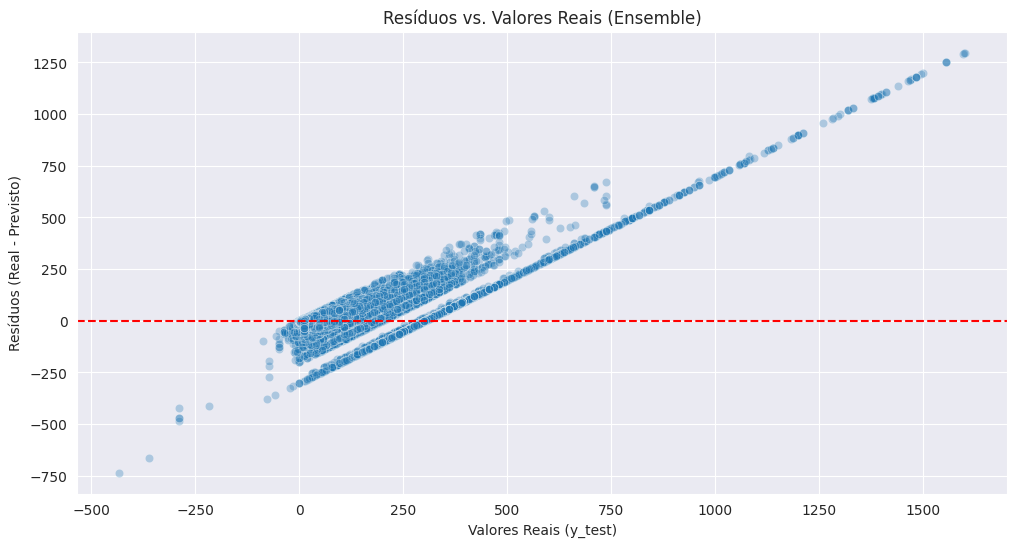

In [7]:
# CÉLULA 7: ENSEMBLE AVANÇADO (STACKING COM LGBM) E AVALIAÇÃO FINAL

print("\n_Avaliando o desempenho dos modelos individuais (Out-of-Fold)..._")
# Nota: Avaliamos OOF no último split de validação para ter uma ideia do desempenho antes do ensemble
val_indices_final = splits[-1][0] # Usando os índices do último fold de validação
lgbm_oof_score = wmate(y.iloc[val_indices_final], oof_preds['lgbm'][val_indices_final])
xgb_oof_score = wmate(y.iloc[val_indices_final], oof_preds['xgb'][val_indices_final])
cat_oof_score = wmate(y.iloc[val_indices_final], oof_preds['cat'][val_indices_final])

print(f"  LGBM OOF WMATE: {lgbm_oof_score:.5f}")
print(f"  XGB OOF WMATE:  {xgb_oof_score:.5f}")
print(f"  CAT OOF WMATE:  {cat_oof_score:.5f}")

# --- Stacking Ensemble com LGBM como Meta-Modelo ---
print("\n_Criando meta-features para o Stacking Ensemble..._")
meta_features_train = pd.DataFrame({
    'lgbm_pred': oof_preds['lgbm'][train_full_indices],
    'xgb_pred': oof_preds['xgb'][train_full_indices],
    'cat_pred': oof_preds['cat'][train_full_indices]
})
meta_features_test = pd.DataFrame({
    'lgbm_pred': np.mean(test_preds['lgbm'], axis=0),
    'xgb_pred': np.mean(test_preds['xgb'], axis=0),
    'cat_pred': np.mean(test_preds['cat'], axis=0)
})

print("Treinando o Meta-Modelo (LightGBM)...")
meta_model = lgb.LGBMRegressor(random_state=42, objective='regression_l1', n_estimators=500, learning_rate=0.05)
meta_model.fit(meta_features_train, y_train_full)
ensemble_test_final = meta_model.predict(meta_features_test)
ensemble_test_final[ensemble_test_final < 0] = 0

# --- Avaliação Final ---
print("\n--- RESULTADOS FINAIS DO STACKING ENSEMBLE ---")
wmate_final = wmate(y_test, ensemble_test_final)
mae_final = mean_absolute_error(y_test, ensemble_test_final)
r2_final = r2_score(y_test, ensemble_test_final)

print(f"  WMATE (Métrica Principal): {wmate_final:.5f}")
print(f"  MAE (Erro Absoluto Médio): {mae_final:.4f}")
print(f"  R² (Coeficiente de Determinação): {r2_final:.4f}")

# Exibir os pesos que o meta-modelo aprendeu (importância das features)
print("\nImportância das features do Meta-Modelo (pesos do ensemble):")
feature_importances = pd.DataFrame({
    'Modelo Base': meta_model.feature_name_,
    'Importância': meta_model.feature_importances_
}).sort_values(by='Importância', ascending=False)
print(feature_importances)

# --- Análise de Resíduos ---
print("\n_Analisando os resíduos do modelo de ensemble..._")
residuals = y_test - ensemble_test_final
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Reais (Ensemble)')
plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Resíduos (Real - Previsto)')
plt.grid(True)
plt.show()

In [8]:
# CÉLULA 8: GERAÇÃO DO ARQUIVO DE SUBMISSÃO FINAL (CORRIGIDA)

print("Iniciando a criação do arquivo de submissão...")

# --- CORREÇÃO: Definindo a variável base_path ---
# Garantimos que a variável para o caminho dos arquivos esteja definida nesta célula.
base_path = './' # Use './' para o diretório atual.

# O 'X_test' da Célula 6 contém as features para o período de previsão.
# Precisamos dos identificadores 'internal_product_id' e 'internal_store_id' deste conjunto.
# Vamos buscar os identificadores originais que correspondem aos índices de X_test.

# Carregamos o checkpoint novamente apenas para pegar os IDs sem alterar o X e y atuais.
# ATENÇÃO: Certifique-se de que o caminho aqui está correto!
checkpoint_path = f'{base_path}df_model_ready_final_v2.parquet'
df_com_ids = pd.read_parquet(checkpoint_path, columns=['internal_product_id', 'internal_store_id'])
ids_test = df_com_ids.iloc[test_indices].reset_index(drop=True)
del df_com_ids; gc.collect()


# Criamos o DataFrame de submissão
submission_df = pd.DataFrame({
    'internal_product_id': ids_test['internal_product_id'],
    'internal_store_id': ids_test['internal_store_id'],
    'target': ensemble_test_final  # Essas são as previsões finais do seu ensemble
})

# A agregação é necessária porque o TimeSeriesSplit pode criar previsões para o mesmo
# produto/loja em dias diferentes dentro da janela de teste. O desafio pede uma única
# previsão por produto/loja para os próximos 7 dias.
# Agregamos pegando a primeira previsão para cada combinação única.
submission_final = submission_df.groupby(['internal_product_id', 'internal_store_id']).first().reset_index()


# Garante que não haja valores negativos (uma boa prática)
submission_final['target'] = submission_final['target'].clip(lower=0)

# Salva no formato exigido
submission_path = f'{base_path}submission.csv'
submission_final.to_csv(submission_path, index=False, sep=';')

print(f"\n✅ Arquivo de submissão criado com {len(submission_final):,} linhas.")
print(f"Salvo em: {submission_path}")

# Exibe as primeiras linhas do arquivo para verificação
print("\nPré-visualização do arquivo de submissão:")
print(submission_final.head())

Iniciando a criação do arquivo de submissão...

✅ Arquivo de submissão criado com 64,252 linhas.
Salvo em: ./submission.csv

Pré-visualização do arquivo de submissão:
   internal_product_id    internal_store_id        target
0  7205856375132980299  2729990452775663240  8.018319e-11
1  7205856375132980299  2743334666979440381  1.000022e+00
2  7205856375132980299  2885903432017122279  1.000022e+00
3  7205856375132980299  2961728766576743186  1.000022e+00
4  7205856375132980299  3129863188908587928  1.000022e+00
